# Tracing

In [1]:
import os
from google.colab import userdata

os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "default"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "weekend_party"

# Getting started

Let's invoke the Gemini with a simple text input:

In [9]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [10]:
google_api_key = userdata.get('GOOGLE_API_KEY')

In [11]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    google_api_key=google_api_key)

In [12]:
from langchain_core.runnables import Runnable
isinstance(llm, Runnable)

True

In [13]:
result = llm.invoke("What is the capital of the USA?")
print(result.content)

[{'type': 'text', 'text': 'The capital of the USA is **Washington, D.C.**', 'extras': {'signature': 'EoUCCoICAb4+9vtrYVwpCqPeq86Df1ikHx9/4tGJwynZDBaGHqVXyTvksRDuzjwORKgv4plWIXYFmwdYOA3OvE3LySWxXG/dRcKU9/wN5tjt8n9zHqFrpur9XJVZ2uOLKfal9Y0HODfgIio9HxHcKvj6wnS1s71Xqv9z1mOLlwrGX3XI6J/PKFsPLq9ztDJQ7ENJH/g0huFVTPNyH7Qp63UJMHm62gykKmOPBDt/CS7eh413JTugLeBPgJkWkKybi/ttTa9j13+ZzW4iYhH4Lqp5hcp5gQUq5owIG2C4oI/WgiVaY3bBARu7wqELvDFFRmP3r1H4JMvGwha6ZjwyUUbmAiK/LywR'}}]


In [14]:
from langchain_core.output_parsers import StrOutputParser

result_text = (llm | StrOutputParser()).invoke("What is the capital of the USA?")

In [15]:
print(result_text)

The capital of the USA is **Washington, D.C.**


In [16]:
print(result.usage_metadata)

{'input_tokens': 9, 'output_tokens': 65, 'total_tokens': 74, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 52}}


In [17]:
from langchain_core.messages import HumanMessage

user_input = HumanMessage(content="What is the capital of the USA?")

In [18]:
step1 = llm.invoke([user_input])

In [19]:
type(step1)

langchain_core.messages.ai.AIMessage

In [20]:
print(step1.content)

[{'type': 'text', 'text': 'The capital of the USA is **Washington, D.C.**', 'extras': {'signature': 'EoECCv4BAb4+9vuIda4zS+Y9NQR1R33z8JXset0AAp68o1EYPCqOqcMjz+GqbYxhGLgVEtpfe/cfLrvRqtgx26hPabfjsiUu6IMsORpKnKwyUlvwYxbM5XVMnXq1UrWXk8f+wJ6yUErSimStcXLD90XUAFYJYtEhWRlkTF5qQmgjVLJWOyTw9efnLNJIa5Pyct1p6tHlTmOTKJZ3Zs79WOa5B667IL0pf+0G506o5sicqz8tuhUNAa/udoU04XJYV0sa/EPDGmUeqLWGeRMbvnWHKry0uSajG9iimFI1RsDeFSsyzOjYvHlQGq0PjwsTCglB9/MqJBQNOkTxDBB73iqQd/c='}}]


In [21]:
print(step1.usage_metadata)

{'input_tokens': 9, 'output_tokens': 67, 'total_tokens': 76, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 54}}


In [22]:
from langchain_core.prompts import PromptTemplate

prompt_template = (
    "Be concise and answer user's question carefully.\n\n"
    "QUESTION:\n{question}\n"
)

question = "What is the capital of the USA?"
lc_prompt_template = PromptTemplate.from_template(prompt_template)


In [23]:
lc_prompt_template.invoke({"question": question})

StringPromptValue(text="Be concise and answer user's question carefully.\n\nQUESTION:\nWhat is the capital of the USA?\n")

In [24]:
from langchain_core.output_parsers import StrOutputParser

chain = lc_prompt_template | llm | StrOutputParser()
result = chain.invoke({"question": question})

In [25]:
print(result)

Washington, D.C.


A special placeholder for messages:

In [26]:
from langchain_core.prompts import ChatPromptTemplate, HumanMessagePromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import SystemMessagePromptTemplate


msg_template = HumanMessagePromptTemplate.from_template(prompt_template)
msg_example = msg_template.format(question=question)

print(msg_example)


content="Be concise and answer user's question carefully.\n\nQUESTION:\nWhat is the capital of the USA?\n" additional_kwargs={} response_metadata={}


In [27]:
chat_prompt_template = ChatPromptTemplate.from_messages([SystemMessage(content="You are a helpful assistant."), msg_template])
chain = chat_prompt_template | llm | StrOutputParser()
chain.invoke({"question": question})

'Washington, D.C.'

In [28]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

chat_prompt_template = ChatPromptTemplate.from_messages(
    [("system", "You are a helpful assistant."),
     ("placeholder", "{history}"),
     # same as MessagesPlaceholder("history"),
     ("human", prompt_template)])

In [29]:
chat_prompt_template.invoke(question)

ChatPromptValue(messages=[SystemMessage(content='You are a helpful assistant.', additional_kwargs={}, response_metadata={}), HumanMessage(content="Be concise and answer user's question carefully.\n\nQUESTION:\nWhat is the capital of the USA?\n", additional_kwargs={}, response_metadata={})])

In [30]:
len(chat_prompt_template.invoke(question).messages)

2

In [31]:
len(chat_prompt_template.invoke({"question": question, "history": [("user", "hi"), ("ai", "how can I help?")]}).messages)

4

In [32]:
def increment_by_one(x: int) -> int:
 return x + 1


def fake_llm(x: int) -> str:
 return f"Result = {x}"

In [33]:
from langchain_core.runnables import RunnableLambda

chain = (
   increment_by_one | RunnableLambda(fake_llm)
)


result = chain.invoke(1)
print(result)

Result = 2


In [34]:
from langchain_core.runnables import RunnableSequence


a = increment_by_one | RunnableLambda(fake_llm)

b = RunnableSequence(RunnableLambda(increment_by_one), RunnableLambda(fake_llm))

print(a == b)


True


In [35]:
b.invoke(2)

'Result = 3'

In [36]:
from langchain_core.callbacks import UsageMetadataCallbackHandler

cb = UsageMetadataCallbackHandler()
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", google_api_key=google_api_key, callbacks=[cb])

In [37]:
chain = lc_prompt_template | llm | StrOutputParser()
chain.invoke({"question": question})

'Washington, D.C.'

In [38]:
print(cb)

{'gemini-3-flash-preview': {'input_tokens': 24, 'output_tokens': 65, 'total_tokens': 89, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 59}}}


In [39]:
chain.invoke({"question": "What is the capital of Germany?"})

'The capital of Germany is **Berlin**.'

In [40]:
print(cb)

{'gemini-3-flash-preview': {'total_tokens': 151, 'input_token_details': {'cache_read': 0}, 'output_tokens': 104, 'output_token_details': {'reasoning': 90}, 'input_tokens': 47}}


In [2]:
!curl -L -o Chinook.db https://storage.googleapis.com/benchmarks-artifacts/chinook/Chinook.db

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  892k  100  892k    0     0  4015k      0 --:--:-- --:--:-- --:--:-- 4073k


In [3]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")


In [4]:
print(f"Dialect: {db.dialect}")


Dialect: sqlite


In [5]:
print(f"Available tables: {db.get_usable_table_names()}")


Available tables: ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


In [6]:
print(f'Sample output: {db.run("SELECT * FROM Genre LIMIT 5;")}')

Sample output: [(1, 'Rock'), (2, 'Jazz'), (3, 'Metal'), (4, 'Alternative & Punk'), (5, 'Rock And Roll')]


In [41]:
llm = ChatGoogleGenerativeAI(model="gemini-3.1-pro-preview", google_api_key=google_api_key)

In [42]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=db, llm=llm)

tools = toolkit.get_tools()

for tool in tools:
    print(f"{tool.name}: {tool.description}\n")

sql_db_query: Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.

sql_db_schema: Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3

sql_db_list_tables: Input is an empty string, output is a comma-separated list of tables in the database.

sql_db_query_checker: Use this tool to double check if your query is correct before executing it. Always use this tool before executing a query with sql_db_query!



In [43]:
system_prompt = """
You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct SQL query to run, then look at the results of the query and return the answer.

**INSTRUCTIONS**:
* Use sqlite dialect
* Never query for all the columns from a specific table, only ask for the relevant columns given the question.
* Double check your query before executing it.
* If you get an error while executing a query, rewrite the query and try again.
* Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most 100 results.
* Avoid any DML statements (INSERT, UPDATE, DELETE, DROP etc.)
* Before the start, ALWAYS look at the tables in the database to see what you can query
* Always check the schema of the most relevant tables
"""

In [45]:
from langchain.agents import create_agent


agent = create_agent(
    llm,
    tools,
    system_prompt=system_prompt,
)

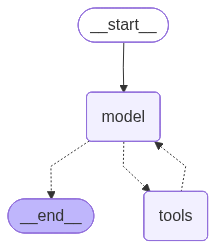

In [46]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [47]:
question = "Show the invoices of customers who are from Brazil"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Show the invoices of customers who are from Brazil
================================== Ai Message ==================================

[]
Tool Calls:
  sql_db_list_tables (9653a390-1ae1-46d5-a3fc-80d610881010)
 Call ID: 9653a390-1ae1-46d5-a3fc-80d610881010
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================

[]
Tool Calls:
  sql_db_schema (10f229c7-1b9c-4f94-8200-4465d686e8df)
 Call ID: 10f229c7-1b9c-4f94-8200-4465d686e8df
  Args:
    table_names: Customer, Invoice
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Customer" (
	"CustomerId" INTEGER NOT NULL, 
	"FirstName" NVARCHAR(40) NOT NULL, 
	

In [51]:
from langchain_core.messages import get_buffer_string


merged_text = get_buffer_string([step["messages"][-1]])

print(merged_text)

AI: Here are the invoices for customers who are from Brazil:

```sql
SELECT i.* 
FROM Invoice i 
JOIN Customer c ON i.CustomerId = c.CustomerId 
WHERE c.Country = 'Brazil' 
LIMIT 100;
```

The results show 35 invoices associated with customers in Brazil. Each invoice includes details like the invoice ID, customer ID, invoice date, billing address, city, state, country, postal code, and the total amount. For example, some of the totals are $13.86, $8.91, $5.94, $3.96, $1.98, and $0.99. All the billing countries for these invoices confirm they are billed in "Brazil".


In [52]:
question = " How many Invoices were there in 2009 and 2011? What are the respective total sales for each of those years?"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

 How many Invoices were there in 2009 and 2011? What are the respective total sales for each of those years?
================================== Ai Message ==================================

[]
Tool Calls:
  sql_db_list_tables (9127e032-9abf-49bd-91b3-5d962e15a0a5)
 Call ID: 9127e032-9abf-49bd-91b3-5d962e15a0a5
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================

[]
Tool Calls:
  sql_db_schema (444ba0a9-3d58-447b-a459-90f0c1aafe2a)
 Call ID: 444ba0a9-3d58-447b-a459-90f0c1aafe2a
  Args:
    table_names: Invoice
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Invoice" (
	"InvoiceId" INTEGER NOT

# Intro to LangGraph

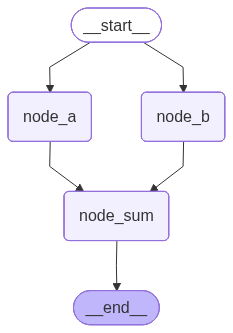

In [54]:
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph import StateGraph, START, END

class CustomState(TypedDict):
    a: int
    b: int
    result: int


def _node_a(state):
    return {"a": 1}

def _node_b(state):
    return {"b": 2}

def _node_sum(state):
    a = state["a"]
    b = state["b"]
    return {"result": a+b}

builder = StateGraph(CustomState)
builder.add_node("node_a", _node_a)
builder.add_node("node_b", _node_b)
builder.add_node("node_sum", _node_sum)

builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_edge("node_a", "node_sum")
builder.add_edge("node_b", "node_sum")
builder.add_edge("node_sum", END)

workflow = builder.compile()

from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [55]:
for event in workflow.stream({}, stream_mode="values"):
  print(event)

{'a': 1, 'b': 2}
{'a': 1, 'b': 2, 'result': 3}


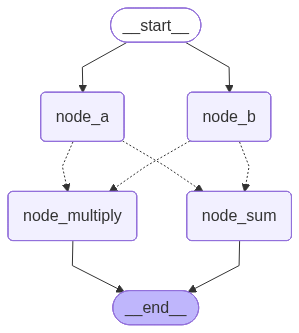

In [56]:
from typing import Literal


class CustomState(TypedDict):
    operation: str
    a: int
    b: int
    result: int

def _node_multiply(state):
    a = state["a"]
    b = state["b"]
    return {"result": a*b}

def _edge(state) -> Literal["node_sum", "node_multiply"]:
    if state["operation"] == "sum":
      return "node_sum"
    return "node_multiply"

builder = StateGraph(CustomState)
builder.add_node("node_a", _node_a)
builder.add_node("node_b", _node_b)
builder.add_node("node_sum", _node_sum)
builder.add_node("node_multiply", _node_multiply)

builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_conditional_edges("node_a", _edge)
builder.add_conditional_edges("node_b", _edge)
builder.add_edge("node_sum", END)
builder.add_edge("node_multiply", END)

workflow = builder.compile()

from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [57]:
initial_state = {"operation": "add"}
for event in workflow.stream(initial_state, stream_mode="values"):
  print(event)

{'operation': 'add'}
{'operation': 'add', 'a': 1, 'b': 2}
{'operation': 'add', 'a': 1, 'b': 2, 'result': 2}


In [58]:
for event in workflow.stream({'operation': 'multiply'}, stream_mode="values"):
  print(event)

{'operation': 'multiply'}
{'operation': 'multiply', 'a': 1, 'b': 2}
{'operation': 'multiply', 'a': 1, 'b': 2, 'result': 2}


In [59]:
result = await workflow.ainvoke(initial_state)
print(result)

{'operation': 'add', 'a': 1, 'b': 2, 'result': 2}


Now, let's take at reducers. We saw the default reducer - it replaces the value in the state. Another option is to use a built-in reducer, for example `add` with a list:

In [60]:
from operator import add

add([1, 2], [3])

[1, 2, 3]

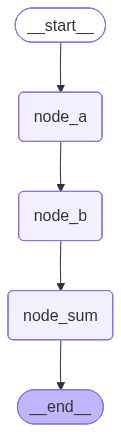

In [61]:
from operator import add
from typing import Annotated

class CustomState(TypedDict):
    values: Annotated[list[int], add]
    result: int


def _node_a(state):
    return {"values": [1]}

def _node_b(state):
    return {"values": [2]}

def _node_sum(state):
    return {"result": sum(state["values"])}

builder = StateGraph(CustomState)
builder.add_node("node_a", _node_a)
builder.add_node("node_b", _node_b)
builder.add_node("node_sum", _node_sum)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", "node_sum")
builder.add_edge("node_sum", END)

workflow = builder.compile()

from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [62]:
workflow.invoke({"values": [5]})

{'values': [5, 1, 2], 'result': 8}

In [63]:
for event in workflow.stream({}, stream_mode="values"):
  print(event)

{'values': [1]}
{'values': [1, 2]}
{'values': [1, 2], 'result': 3}


Now, let's take a look at custom reducers:

In [64]:
def my_reducer(left: int, right: int) -> int:
  if right:
    return left + right
  return left

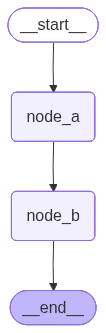

In [65]:
from operator import add
from typing import Annotated

class CustomState(TypedDict):
    value: Annotated[int, my_reducer]


def _node_a(state):
    return {"value": 1}

def _node_b(state):
    return {"value": 2}

builder = StateGraph(CustomState)
builder.add_node("node_a", _node_a)
builder.add_node("node_b", _node_b)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)

workflow = builder.compile()

from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [66]:
for event in workflow.stream({}, stream_mode="values"):
  print(event)

{'value': 1}
{'value': 3}


In [67]:
step2 = llm.invoke([user_input, step1, ("human", "How many people live there?")])

In [68]:
print(step2.content)

[{'type': 'text', 'text': 'As of recent estimates (2023), the population of Washington, D.C. proper is approximately **670,000 to 690,000** people. \n\nHowever, if you include the entire Washington metropolitan area—which encompasses the surrounding suburbs in Maryland, Virginia, and a small part of West Virginia—the population is much larger, at over **6.3 million** people.', 'extras': {'signature': 'Eq4KCqsKAb4+9vsVcRrNkNX5rfJw88DrB6kO5lM0Sy3fZH7ixwsGHvfhKa+17PANOMpYbV30RIOf0WMZHfxA0JslcZKbKE0rJbUb5AFXzv9eN4tT4BIL/77bhjY6/yalUmu99yuJfYhtyaMmfWkW+LVmNnV0owT8nd2ZGg9tSYRuYGsG65JZWow5s5QIdZHN2x8aN/QLunXHtxO+ZetvQQSqPFKqagt0TmvsbudPP6d0c6Ph2fQmt3CKN4prmj2jV9dGYi5z2tqy4N7CzppqNroLRBCf7bKslFGbO0btj6gI5hJnQDPHOc3PF6hfaLsEvE0zCxC+hVQcSC/cI2CnX9wTlew4vs6jq3ugS+hYbG/IKTE5DzBexSCb4F8I3QseF5xMTo9HYKAZ7G7Qfnlx93468ckW8cIcsLTfsooWWaNWuQM71/ax0eeCfK3aTwQQdwo/Bv9VWy5Nm80T3JaLVjTDkiKn5CroU9SjWUwBxykbOkDftKVmmadtToTR61l4z1H7iYxumg0Ish/xUvyFZBMBw4MYky3Rkk69iIjdprfU4FplXLD5hwpd+f9t9v5d+2z8oTsPxWLrfWXcU1y

# Tracing

In [69]:
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", google_api_key=google_api_key)
result = llm.invoke("What is the capital of the USA?")
print(result.content)

[{'type': 'text', 'text': 'The capital of the USA is **Washington, D.C.**', 'extras': {'signature': 'EpIBCo8BAb4+9vs+xLVSJkYZmcPnqr+ssgYMProPHvkFDu6BDjzICBdqJMff9lrkeY/v1mX1wpBUW53ajK6MWRlrx+K/K+nJQ+OZTB5EZmOY4rS35rpmWerNuF6fH55IWIYMDCs+vGwIFIhIrnxUfPGHSkYrIQJ6wgfjvkM11XKRxrqLq3GZJbJWuyUA8khEU5RXgVQ='}}]


In [70]:
from langsmith import traceable

@traceable
def run():
  return llm.invoke("What is the capital of the USA?")

In [71]:
run()

AIMessage(content=[{'type': 'text', 'text': 'The capital of the USA is **Washington, D.C.**', 'extras': {'signature': 'EvkBCvYBAb4+9vsaTkgcMOiNqEvdGXVKizotFg9iZmVa10xbjgh+NwS464btemIiynLmT3pZAd/pmA8wm9aUhxa9jxax4wXDVgjBGbPdr7ScWdIK4dkHAn3WQQlTL3gLXlHk/5w6xKleT2enkqmk2AXiwm29KrwCUwdReIdh+Wy4wH76L1/c3ZWKGnaZuzRqdu8lr02rEA/wPmyCLRzguah84HAp2RwD4VJLIyDzWqws0M2K24M+ly7VqS2vJHJbbk34MWV6iqzJqe2EnOtOVBlWodxv4qytiGhC0cZ8Ez+pbQKEauOGu/EPvNqbxShAs+xuBVe9A4PJhGXH'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cec2e-4356-73f1-9922-0b9a3d759fc7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 64, 'total_tokens': 73, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 51}})

# Using external tools

In [72]:
from langchain_core.prompts import PromptTemplate


Let's demonstrate how we can instruct an LLM to use an external tool:

In [73]:
task = (
    "In 1990, the average cost of a gallon of gasoline was $1.16. If the "
    "inflation rate from 1990 to today has been a cumulative 180%, what would "
    "that gallon of gas cost in today's money? How does that compare to the "
    "current average price of gas?"
)

raw_prompt_template = (
  "You have access to search engine that provides you an "
  "information about current events. "
  "Given the question, decide whether you need an additional "
  "information from the search engine, and if yes, reply with 'SEARCH: "
   "<generated query>'. Only if you know enough to answer the user "
   "then reply with 'RESPONSE <final response>').\n"
   "Now, act to answer a user question:\n{question}"
)
prompt_template = PromptTemplate.from_template(raw_prompt_template)

response = (prompt_template | llm).invoke(task)
print(response.content)

[{'type': 'text', 'text': 'SEARCH: current average price of gas in the US 2024', 'extras': {'signature': 'EvUFCvIFAb4+9vtoFcYJ4yE49UxTOgos8LavK52Sp2Ue9vzPL/v0b/NSdH7Kks4duVTzNe2mG0uOz8rjHqpEP8gLujG4Z6hl5SVRD3tATqmhI7wo5/KvUMYgMfT910LzDeQ8SLbh6sJKWg5oq/w3AkfLvr9YxDXw9jqt3oGa8EV4+TtWTcBWd2/+5nKP6Gm9NiasoBK2r0SZp5psbMk4YnTKAC05wDLintrBdmpKLJPMPTznvW6QpaG+KMSR5l0X2rjo3C5p0QEvFOSkSqSESQ9Th33YcZzKy920LJFseLMzvrCeAggQIVBlit4Jw2HdWHLUv4NF17PxrD6UMGFG9KugxSknQjV339tq/kraABBoQiMzXpaVsjqMTbBkxRsRvlFDrfCKetOPYTMAxHTkr2ObKWtp1qEwYcuvkpRYXd9hy/T/uVj3TrhR0Fy09yiP97wDnHrJhVKrCMilgcvtkxrMlJGBricoEU/XsdJNTd1Lfb56FHgLrzKryv0LY1wmhNt9sBM7PTQGA+MHuMdQWqz5TqI9bsYA3PGAIEoYcHOhpCiSlMHTM9XSpxbhmkK+8TfTA0jF7VH90qR8djQHKl8k8iDBYPy6cYCVHFn0L6th6dPN43YI951ELvWN75d8woezMefJZmUXQ5Sv9gJrmirt3QZ3DHhOMETa7MOhOVZP4NuVIM8iF5Vg8gylIs8lc7w8T6Skt35nwHCY8jq/L4hfT382Y9SPCQ9f+K7HD6ewY9nvhAYFQf4LiVg3sW7hpf8l/ctBfYqGQHr1zTuDBw1UBK0StWyB83UfB/3cSL9dqk9hpBDYIr2rpBTrFOmRT/a4O68jDlElYTTWtzth22qVOlMnsWbPve0n8FYSIwvKeGQhAfD8VYJXD0Usgs

Technical note: a _PromptTemplate_ allows you substitute variables when executing the chain:

In [74]:
prompt_template.invoke({"question": "TEST"})

StringPromptValue(text="You have access to search engine that provides you an information about current events. Given the question, decide whether you need an additional information from the search engine, and if yes, reply with 'SEARCH: <generated query>'. Only if you know enough to answer the user then reply with 'RESPONSE <final response>').\nNow, act to answer a user question:\nTEST")

In [75]:
query = "average gas price today"
search_result = "3.349"

In [76]:
raw_prompt_template = (
  "You have access to search engine that provides you an "
  "information about current events. "
  "Given the question, decide whether you need an additional "
  "information from the search engine, and if yes, reply with 'SEARCH: "
   "<generated query>'. Only if you know enough to answer the user "
   "then reply with 'RESPONSE <final response>').\n"
   "Today is {date}."
   "Now, act to answer a user question and "
   "take into account your previous actions:\n"
   "HUMAN: {question}\n"
   "AI: SEARCH: {query}\n"
   "RESPONSE FROM SEARCH: {search_result}\n"
)
prompt_template = PromptTemplate.from_template(raw_prompt_template)

result = (prompt_template | llm | StrOutputParser()).invoke({"question": task, "query": query, "search_result": search_result, "date": "Feb 2026"})
print(result)

RESPONSE To calculate the cost of a gallon of gas in today's money based on a 180% cumulative inflation rate, you multiply the 1990 price by the inflation factor.

1. **Calculate the inflation-adjusted price:**
   - Base price (1990): $1.16
   - Cumulative inflation: 180% (or 1.80)
   - Formula: $1.16 \times (1 + 1.80) = $1.16 \times 2.80$
   - **Adjusted Price: $3.248 (approximately $3.25)**

2. **Compare to the current average price:**
   - The current average price of gasoline is **$3.349**.
   - Comparing the two, today's gas is slightly more expensive than the inflation-adjusted 1990 price. The current price is about **$0.10 higher** (or roughly 3% more) than it would be if it had tracked perfectly with the specified inflation rate.


# Creating tools with LangChain

Let's use a DuckDuckGo search through LangChain:

In [77]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()
print(f"Tool's name = {search.name}")
print(f"Tool's name = {search.description}")
print(f"Tool's arg schema = {search.args_schema}")

Tool's name = duckduckgo_search
Tool's name = A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.
Tool's arg schema = <class 'langchain_community.tools.ddg_search.tool.DDGInput'>


In [78]:
from langchain_community.tools.ddg_search.tool import DDGInput

print(DDGInput.model_fields)

{'query': FieldInfo(annotation=str, required=True, description='search query to look up')}


In [79]:
query = "What is the weather in Munich like tomorrow?"
search_input = DDGInput(query=query)
result = search.invoke(search_input.model_dump())
print(result)

2 days ago -Tomorrow, weather will beunstable, and a mix of gloomy, bright, low-visibility and wet weatheris predicted. The temperature will be between the lowest temperature of 4°C and the highest temperature of 13°C. The warmest part of the day will ... November 23, 2025 -The weather tomorrow in Munich will bea bit hotter than today, with max temperatures of 2°. The rain is expected to get stronger, the expected precipitation are 13 mm. 5 days ago -Get the detailed weather forecast for Munich, Bavaria, Germany. Access daily, 10 day and 16 day views, maps, meteograms and timelines for accurate predictions. 2 days ago -Expectscattered cloudsin Munich, Germany with a maximum temperature of 14°C, maximum UV of 2 (Low) and 10 hours of bright sunshine. There are 0 mm of rainfall expected and a gentle breeze of 13 kph from the east. 4 days ago -Given the forecast of15 °C with a 0% chance of rain, we advise checking our "What to wear today" section for recommendations. There, you will find t

In [ ]:
isinstance(result, str)

True

Another example - let's use a web API to instruct an LLM to get the latest information about FX rates:

In [80]:
api_spec = """
openapi: 3.0.0
info:
  title: Frankfurter Currency Exchange API
  version: v1
  description: API for retrieving currency exchange rates. Pay attention to the base currency and change it if needed.

servers:
  - url: https://api.frankfurter.dev/v1

paths:
  /v1/{date}:
    get:
      summary: Get exchange rates for a specific date.
      parameters:
        - in: path
          name: date
          schema:
            type: string
            pattern: '^\d{4}-\d{2}-\d{2}$' # YYYY-MM-DD format
          required: true
          description: The date for which to retrieve exchange rates.  Use YYYY-MM-DD format.  Example: 2009-01-04
        - in: query
          name: symbols
          schema:
            type: string
          description: Comma-separated list of currency symbols to retrieve rates for. Example: GBP,USD,EUR

  /v1/latest:
    get:
      summary: Get the latest exchange rates.
      parameters:
        - in: query
          name: symbols
          schema:
            type: string
          description: Comma-separated list of currency symbols to retrieve rates for. Example: CHF,GBP
        - in: query
          name: base
          schema:
            type: string
          description: The base currency for the exchange rates. If not provided, EUR is used as a base currency. Example: USD
"""

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_502/2022118673.py:20: SyntaxWarning: invalid escape sequence '\d'
  pattern: '^\d{4}-\d{2}-\d{2}$' # YYYY-MM-DD format


In [81]:
from langchain_community.agent_toolkits.openapi.toolkit import RequestsToolkit
from langchain_community.utilities.requests import TextRequestsWrapper

toolkit = RequestsToolkit(
    requests_wrapper=TextRequestsWrapper(headers={}),
    allow_dangerous_requests=True,
)

for tool in toolkit.get_tools():
  print(tool.name)

requests_get
requests_post
requests_patch
requests_put
requests_delete


In [82]:
from langchain.agents import create_agent

system_message = (
  "You're given the API spec:\n{api_spec}\n"
  "If possible, use this API if a user asks about foreign exchange rates. "
)

agent = create_agent(llm, toolkit.get_tools(), system_prompt=system_message.format(api_spec=api_spec))

In [83]:
query = "What is the swiss franc to US dollar exchange rate?"

for event in agent.stream({"messages": [("human", query)]}, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the swiss franc to US dollar exchange rate?
================================== Ai Message ==================================

[]
Tool Calls:
  requests_get (6ed5b6fc-d45b-4dd6-accd-0b5c396823b9)
 Call ID: 6ed5b6fc-d45b-4dd6-accd-0b5c396823b9
  Args:
    url: https://api.frankfurter.dev/v1/latest?base=CHF&symbols=USD
================================= Tool Message =================================
Name: requests_get

{"amount":1.0,"base":"CHF","date":"2026-03-13","rates":{"USD":1.2703}}
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The current exchange rate is 1 Swiss Franc (CHF) to 1.2703 US Dollars (USD).', 'extras': {'signature': 'EtIBCs8BAb4+9vvx4JWj0nFrP6h/ooGiA+Yy0yigLCI4efTusAs1/Cg3iZo9ueOea32VJxDenqs7HwEAptDy5ubOwWcvTM8tNkXZmiFEalcFs5Y5/wArU5THCALr5supcCLgfbh1Fao3bOZuFWDc5ntvWjVDBlHec3E1s0Se0fpKb+tXmbN4H/4sUBxe3GvMqvFnE7/RI38ZnQ1

In [84]:
response = llm.invoke([
    ("system", system_message.format(api_spec=api_spec)),
     ("human", "What is the swiss franc to US dollar exchange rate?")], tools=toolkit.get_tools())

In [85]:
tool_calls = response.tool_calls
print(tool_calls)

[{'name': 'requests_get', 'args': {'__arg1': 'https://api.frankfurter.dev/v1/latest?base=CHF&symbols=USD'}, 'id': '24cc86ba-eee0-4bc2-b912-94a8f2617d6f', 'type': 'tool_call'}]


In [86]:
tool_calls[0]

{'name': 'requests_get',
 'args': {'__arg1': 'https://api.frankfurter.dev/v1/latest?base=CHF&symbols=USD'},
 'id': '24cc86ba-eee0-4bc2-b912-94a8f2617d6f',
 'type': 'tool_call'}

In [87]:
toolkit.get_tools()[0].run(tool_calls[0]["args"]["__arg1"])

'{"amount":1.0,"base":"CHF","date":"2026-03-13","rates":{"USD":1.2703}}'

# Defining tools with LangChain

In [88]:
import math
from langchain_core.tools import tool
import numexpr as ne

@tool
def calculator(expression: str) -> str:
    """Calculates a single mathematical expression, incl. complex numbers.

    Always add * to operations, examples:
      73i -> 73*i
      7pi**2 -> 7*pi**2
    """
    math_constants = {"pi": math.pi, "i": 1j, "e": math.exp}
    result = ne.evaluate(expression.strip(), local_dict=math_constants)
    return str(result)

In [89]:
calculator.invoke("2+2")

'4'

In [90]:
from langchain_core.tools import BaseTool

assert isinstance(calculator, BaseTool)
print(f"Tool name: {calculator.name}")
print(f"Tool name: {calculator.description}")
print(f"Tool schema: {calculator.args_schema.model_json_schema()}")

Tool name: calculator
Tool name: Calculates a single mathematical expression, incl. complex numbers.

    Always add * to operations, examples:
      73i -> 73*i
      7pi**2 -> 7*pi**2
Tool schema: {'description': 'Calculates a single mathematical expression, incl. complex numbers.\n\nAlways add * to operations, examples:\n  73i -> 73*i\n  7pi**2 -> 7*pi**2', 'properties': {'expression': {'title': 'Expression', 'type': 'string'}}, 'required': ['expression'], 'title': 'calculator', 'type': 'object'}


In [91]:
print(calculator.args_schema.model_json_schema())

{'description': 'Calculates a single mathematical expression, incl. complex numbers.\n\nAlways add * to operations, examples:\n  73i -> 73*i\n  7pi**2 -> 7*pi**2', 'properties': {'expression': {'title': 'Expression', 'type': 'string'}}, 'required': ['expression'], 'title': 'calculator', 'type': 'object'}


In [92]:
query = "How much is 2+3i squared?"

agent = create_agent(llm, [calculator])

for event in agent.stream({"messages": [("user", query)]}, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

How much is 2+3i squared?
================================== Ai Message ==================================

[]
Tool Calls:
  calculator (326c31a0-2f13-4746-a4d3-4d757b7af057)
 Call ID: 326c31a0-2f13-4746-a4d3-4d757b7af057
  Args:
    expression: (2+3*i)**2
================================= Tool Message =================================
Name: calculator

(-5+12j)
================================== Ai Message ==================================

[{'type': 'text', 'text': 'To find the square of $2 + 3i$, you can use the binomial expansion formula $(a + b)^2 = a^2 + 2ab + b^2$, where $a = 2$ and $b = 3i$:\n\n1.  **Square the first term:** $2^2 = 4$\n2.  **Multiply the terms and double:** $2 \\times (2 \\times 3i) = 12i$\n3.  **Square the second term:** $(3i)^2 = 9i^2$\n    *   Since $i^2 = -1$, this becomes $9 \\times (-1) = -9$\n4.  **Combine the real and imaginary parts:** $4 + 12i - 9 = -5 + 12i$\n\nSo, $(2

In [93]:
question = (
    "I ate 200g of chicken breast, 150g of broccoli, and 50g of brown rice for dinner. "
    #"I ate 200g of chicken breast for dinner. "
    "How many total calories did I consume, and what percentage of my recommended daily "
    "protein intake does this meal provide if my recommended intake is 75g?"
)

system_hint = "Think step-by-step. Always use search tool to get the fresh information about events or public facts that can change over time. Always use calculator tool for math computations."

agent = create_agent(
    llm, [calculator, search],
    system_prompt=system_hint)

for event in agent.stream({"messages": [("user", question)]}, stream_mode="updates"):
    for _, event_values in event.items():
      for message in event_values["messages"]:
        message.pretty_print()

================================== Ai Message ==================================

[]
Tool Calls:
  duckduckgo_search (7df6e8ef-ba2d-4adf-8051-1b80957669cc)
 Call ID: 7df6e8ef-ba2d-4adf-8051-1b80957669cc
  Args:
    query: nutritional info 200g chicken breast 150g broccoli 50g brown rice cooked
================================= Tool Message =================================
Name: duckduckgo_search

ChickenCalories &NutritionalValue Calculator Calculate accurate calories and completenutritionalinformation for differentchickencuts and preparations. Get detailed nutrition facts including protein, fats, vitamins, and minerals for this high-quality protein source. A clear, evidence-based breakdown of calories, protein, fat, and carbs in200gcookedchickenbreast— plus how cooking method, weighing timing, and dietary goals affect your numbers. Chickenwith mixed vegetables (150g) contain 1 gram of sugar, 14 grams of protein, 4 grams of fat, 4 grams of fiber, and 9 grams of carbohydrates. Thenutri

In [94]:
from langchain_core.runnables import RunnableLambda, RunnableConfig
from langchain_core.tools import tool, convert_runnable_to_tool


def calculator(expression: str) -> str:
    math_constants = {"pi": math.pi, "i": 1j, "e": math.exp}
    result = ne.evaluate(expression.strip(), local_dict=math_constants)
    return str(result)

calculator_with_retry = RunnableLambda(calculator).with_retry(
    wait_exponential_jitter=True,
    stop_after_attempt=3,
)

calculator_tool = convert_runnable_to_tool(
    calculator_with_retry,
    name="calculator",
    description=(
        "Calculates a single mathematical expression, incl. complex numbers."
        "'\nAlways add * to operations, examples:\n73i -> 73*i\n"
        "7pi**2 -> 7*pi**2"
    ),
    arg_types={"expression": "str"},
)

In [97]:
llm.invoke("How much is (2+3i)**2", tools=[calculator_tool]).tool_calls[0]

{'name': 'calculator',
 'args': {'__arg1': '(2+3*i)**2'},
 'id': '83b8a3cf-5276-4f08-b6ad-2bbf3965807f',
 'type': 'tool_call'}

In [96]:
calculator_tool.invoke({"expression": "(2+3*i)**2"})

'(-5+12j)'

In [95]:
agent = create_agent(llm, [calculator_tool])

for event in agent.stream({"messages": [("user", "How much is (2+3i)^2")]}, stream_mode="updates"):
    for _, event_values in event.items():
      for message in event_values["messages"]:
        message.pretty_print()

================================== Ai Message ==================================

[]
Tool Calls:
  calculator (be723963-d9b4-440f-a26d-bfa47600eec5)
 Call ID: be723963-d9b4-440f-a26d-bfa47600eec5
  Args:
    __arg1: (2+3*i)**2
================================= Tool Message =================================
Name: calculator

(-5+12j)
================================== Ai Message ==================================

[{'type': 'text', 'text': 'To calculate $(2+3i)^2$, you can use the formula for squaring a binomial: $(a+b)^2 = a^2 + 2ab + b^2$.\n\nIn this case, $a = 2$ and $b = 3i$:\n\n1.  **Square the first term:** $2^2 = 4$\n2.  **Multiply the terms and double them:** $2 \\times (2 \\times 3i) = 12i$\n3.  **Square the second term:** $(3i)^2 = 9i^2$. Since $i^2 = -1$, this becomes $-9$.\n\nNow, combine the results:\n$4 + 12i - 9$\n\nCombine the real parts:\n$(4 - 9) + 12i = -5 + 12i$\n\n**Final Answer:**\n$(2+3i)^2 = -5 + 12i$', 'extras': {'signature': 'EvgBCvUBAb4+9vsmajZIJ38SWnMEaqNvvup

# Controlled generation

In [98]:
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from pydantic import BaseModel, Field

class Step(BaseModel):
    """A step that is a part of the plan to solve the task."""
    step: str = Field(description="Description of the step")

class Plan(BaseModel):
    """A plan to solve the task."""
    steps: list[Step]


prompt = PromptTemplate.from_template(
    "Prepare a step-by-step plan to solve the given task.\n"
    "TASK:\n{task}\n"
)


In [99]:
(prompt | llm).invoke({"task": "How to write a bestseller on Amazon about generative AI?"})

AIMessage(content=[{'type': 'text', 'text': 'To write a bestseller on Amazon about Generative AI, you are entering a highly competitive but high-demand market. Success requires a blend of **timely information, authority, and aggressive Amazon-specific marketing.**\n\nHere is your step-by-step plan to move from concept to the #1 New Release badge.\n\n---\n\n### Phase 1: Market Research & Niche Identification\n*The goal is to find a "Blue Ocean" within the crowded AI category.*\n\n1.  **Analyze the Competition:** Use tools like **Publisher Rocket** or **Helium 10** to see which AI books are selling. Look for "Content Gaps" in 1-star and 3-star reviews of current bestsellers (e.g., "too technical," "outdated," or "no practical examples").\n2.  **Define Your Specific Avatar:** Don’t write "AI for Everyone." Pick a niche:\n    *   *AI for Real Estate Agents*\n    *   *The Executive’s Guide to AI Strategy*\n    *   *Generative AI for Fiction Authors*\n3.  **Validate Keyword Demand:** Check A

In [100]:
llm1 = llm.with_structured_output(Plan)

In [101]:
substituted_prompt = prompt.invoke("How to write a bestseller on Amazon about generative AI?")

In [102]:
result = llm1.invoke(substituted_prompt)

In [103]:
result.steps

[Step(step='Perform market research on Amazon to identify high-volume keywords and underserved niches within the Generative AI category.'),
 Step(step='Define a specific target audience, such as non-technical managers, creative artists, or software engineers, to ensure the tone and complexity are appropriate.'),
 Step(step='Develop a unique value proposition and a catchy, keyword-optimized title that clearly states the benefit to the reader.'),
 Step(step='Create a detailed book outline that covers essential topics like Large Language Models, prompt engineering, image generation, and ethical considerations.'),
 Step(step='Write the manuscript, focusing on high-quality content that blends theoretical knowledge with practical, real-world applications and step-by-step tutorials.'),
 Step(step='Undergo professional editing and technical fact-checking to ensure accuracy in a rapidly evolving technological field.'),
 Step(step='Design a high-impact book cover that meets professional standard

In [104]:
chain = prompt | llm.with_structured_output(Plan)
result = chain.invoke("How to write a bestseller on Amazon about generative AI?")
assert isinstance(result, Plan)
print(f"Amount of steps: {len(result.steps)}")
for step in result.steps:
  print(step.step)
  break

Amount of steps: 10
Conduct extensive market research on Amazon to identify high-demand, low-competition sub-niches within the generative AI space, such as prompt engineering for business or AI-driven creative workflows.


In [105]:
type(Plan)

pydantic._internal._model_construction.ModelMetaclass

In [106]:
for step in result.steps:
  print(step.step)

Conduct extensive market research on Amazon to identify high-demand, low-competition sub-niches within the generative AI space, such as prompt engineering for business or AI-driven creative workflows.
Define a specific target audience, such as non-technical executives, software developers, or digital artists, to ensure the tone and technical depth of the content are appropriately aligned.
Develop a unique value proposition and a compelling title that includes high-traffic keywords related to generative AI, LLMs, and productivity.
Create a comprehensive outline that covers fundamental AI concepts, popular tools like ChatGPT and Midjourney, real-world case studies, and future trends.
Write the manuscript with a focus on high-quality, actionable content, ensuring that all technical information is accurate and up-to-date with current industry standards.
Invest in professional editing and proofreading to ensure the writing is polished, authoritative, and free of errors.
Design a professiona

In [107]:
Plan.model_json_schema()

{'$defs': {'Step': {'description': 'A step that is a part of the plan to solve the task.',
   'properties': {'step': {'description': 'Description of the step',
     'title': 'Step',
     'type': 'string'}},
   'required': ['step'],
   'title': 'Step',
   'type': 'object'}},
 'description': 'A plan to solve the task.',
 'properties': {'steps': {'items': {'$ref': '#/$defs/Step'},
   'title': 'Steps',
   'type': 'array'}},
 'required': ['steps'],
 'title': 'Plan',
 'type': 'object'}

In [109]:
plan_schema = {
    "type": "ARRAY",
    "items": {
        "type": "OBJECT",
          "properties": {
              "step": {"type": "STRING"},
          },
      },
}

query = "How to write a bestseller on Amazon about generative AI?"
result = (prompt | llm.with_structured_output(schema=plan_schema, method="json_mode")).invoke(query)

In [110]:
assert(isinstance(result, list))
print(f"Amount of steps: {len(result)}")
print(result[0])

Amount of steps: 10
{'step': 'Conduct market research on Amazon to identify trending sub-topics and gaps in current generative AI literature.'}


In [111]:
from langchain_core.output_parsers import JsonOutputParser
llm_json = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    google_api_key=google_api_key,
    response_mime_type="application/json",
    response_schema=plan_schema)
result = (prompt | llm_json | JsonOutputParser()).invoke(query)
assert(isinstance(result, list))
print(f"Amount of steps: {len(result)}")
print(result[0])

Amount of steps: 10
{'step': 'Identify a profitable sub-niche in Generative AI by analyzing Amazon bestseller lists and keyword demand.'}


In [112]:
from langchain_core.output_parsers import StrOutputParser
response_schema = {"type": "STRING", "enum": ["positive", "negative", "neutral"]}

prompt = PromptTemplate.from_template(
    "Classify the tone of the following customer's review:"
    "\n{review}\n"
)

review = "I like this movie!"
llm_enum = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    google_api_key=google_api_key,
    response_mime_type="application/json",
    response_schema=response_schema)
result = (prompt | llm_enum | StrOutputParser()).invoke(review)
print(result)

"positive"


In [113]:
plan_schema = {
    "type": "ARRAY",
    "items": {
        "type": "OBJECT",
          "properties": {
              "step": {"type": "STRING"},
          },
      },
}

query = "How to write a bestseller on Amazon about generative AI?"
result = (prompt | llm.with_structured_output(schema=plan_schema, method="json_mode")).invoke(query)

In [114]:
assert(isinstance(result, list))
print(f"Amount of steps: {len(result)}")
print(result[0])

Amount of steps: 2
{'step': 'The input provided is a query seeking advice or information rather than a traditional product evaluation.'}


In [115]:
from langchain_core.output_parsers import JsonOutputParser
llm_json = ChatGoogleGenerativeAI(
    model="gemini-3-pro-preview",
    google_api_key=google_api_key,
    response_mime_type="application/json",
    response_schema=plan_schema)
result = (prompt | llm_json | JsonOutputParser()).invoke(query)
assert(isinstance(result, list))
print(f"Amount of steps: {len(result)}")
print(result[0])

Amount of steps: 4
{'step': 'Read the provided customer text.'}


# Plan-and-solve agent

In [116]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

class Plan(BaseModel):
    """Plan to follow in future"""

    steps: list[str] = Field(
        description="different steps to follow, should be in sorted order"
    )

system_prompt_template = (
    "For the given task, come up with a step by step plan.\n"
    "This plan should involve individual tasks, that if executed correctly will "
    "yield the correct answer. Do not add any superfluous steps.\n"
    "The result of the final step should be the final answer. Make sure that each "
    "step has all the information needed - do not skip steps."
)
planner_prompt = ChatPromptTemplate.from_messages(
    [("system", system_prompt_template),
     ("user", "Prepare a plan how to solve the following task:\n{task}\n")])

planner = planner_prompt | ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview", temperature=1.0, google_api_key=google_api_key
).with_structured_output(Plan)

In [117]:
task = "Write a strategic one-pager of building an AI startup?"
plan = planner.invoke(task)

In [118]:
len(plan.steps)

9

In [119]:
from langchain_community.agent_toolkits.load_tools import load_tools

llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", google_api_key=google_api_key)
tools = load_tools(
  tool_names=["ddg-search", "arxiv", "wikipedia"],
  llm=llm
)

In [120]:
from langchain.agents import AgentState
from typing_extensions import TypedDict
from langgraph.managed import IsLastStep
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

class StepState(AgentState):
  plan: str
  step: str
  task: str

system_prompt = (
    "You're a smart assistant that carefully helps to solve complex tasks.\n"
    " Given a general plan to solve a task and a specific step, work on this step. "
    " Don't assume anything, keep in minds things might change and always try to "
    "use tools to double-check yourself.\n"
    " Use a calculator for mathematical computations, use Search to gather"
    "for information about common facts, fresh events and news, use Arxiv to get "
    "ideas on recent research and use Wikipedia for common knowledge."
)

step_template = (
    "Given the task and the plan, try to execute on a specific step of the plan.\n"
    "TASK:\n{task}\n\nPLAN:\n{plan}\n\nSTEP TO EXECUTE:\n{step}\n"
)

execution_agent = create_agent(model=llm, tools=tools+[calculator_tool], state_schema=StepState, system_prompt=system_prompt)

In [121]:
class PlanState(TypedDict):
    task: str
    plan: Plan
    past_steps: Annotated[list[str], add]
    final_response: str


def get_current_step(state: PlanState) -> int:
  """Returns the number of current step to be executed."""
  return len(state.get("past_steps", []))

def get_full_plan(state: PlanState) -> str:
  """Returns formatted plan with step numbers and past results."""
  full_plan = []
  for i, step in enumerate(state["plan"].steps):
    full_step = f"# {i+1}. Planned step: {step}\n"
    if i < get_current_step(state):
      full_step += f"Result: {state['past_steps'][i]}\n"
    full_plan.append(full_step)
  return "\n".join(full_plan)

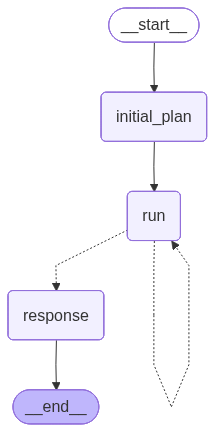

In [122]:
final_prompt = PromptTemplate.from_template(
    "You're a helpful assistant that has executed on a plan."
    "Given the results of the execution, prepare the final response.\n"
    "Don't assume anything\nTASK:\n{task}\n\nPLAN WITH RESUlTS:\n{plan}\n"
    "FINAL RESPONSE:\n"
)

async def _build_initial_plan(state: PlanState) -> PlanState:
  plan = await planner.ainvoke(state["task"])
  return {"plan": plan}

async def _run_step(state: PlanState) -> PlanState:
  plan = state["plan"]
  current_step = get_current_step(state)
  template = ChatPromptTemplate.from_messages([
    ("user", step_template),
  ])

  step = await (template | execution_agent).ainvoke({"plan": get_full_plan(state), "step": plan.steps[current_step], "task": state["task"]})
  return {"past_steps": [step["messages"][-1].content]}

async def _get_final_response(state: PlanState) -> PlanState:
  final_response = await (final_prompt | llm).ainvoke({"task": state["task"], "plan": get_full_plan(state)})
  return {"final_response": final_response}


def _should_continue(state: PlanState) -> Literal["run", "response"]:
  if get_current_step(state) < len(state["plan"].steps):
    return "run"
  return "response"

builder = StateGraph(PlanState)
builder.add_node("initial_plan", _build_initial_plan)
builder.add_node("run", _run_step)
builder.add_node("response", _get_final_response)

builder.add_edge(START, "initial_plan")
builder.add_edge("initial_plan", "run")
builder.add_conditional_edges("run", _should_continue)
builder.add_edge("response", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [123]:
task = "Write a strategic one-pager of building an AI startup"
result = await graph.ainvoke({"task": task})

In [124]:
print(result["final_response"].content)

[{'type': 'text', 'text': '# NexusChain AI: Strategic One-Pager\n\n**Mission:** To transform global supply chain management from reactive "firefighting" to autonomous, predictive resilience by mapping the invisible sub-tiers of global trade.\n\n---\n\n### **1. The Problem: The Multi-Tier Blind Spot**\nModern enterprises have digitized their Tier 1 (direct) supplier relationships but remain largely blind to Tier 2, 3, and 4 dependencies. \n*   **The Financial Impact:** Over 70% of supply chain disruptions originate in these deeper tiers, costing Fortune 500 organizations an average of **$184 million annually**.\n*   **The Regulatory Trigger:** New global mandates (e.g., German LkSG, U.S. UFLPA) now require companies to prove ethical compliance deep within their chains or face fines up to 2% of global turnover.\n*   **The Gap:** Legacy ERPs (SAP, Oracle) are "internal-looking" and rely on manual data entry, leaving a weeks-long information lag during global crises.\n\n### **2. The Soluti

In [125]:
async for output in graph.astream({"task": task}, stream_mode="updates"):
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print("---")
        print(value)
    print("\n---\n")

Output from node 'initial_plan':
---
{'plan': Plan(steps=['Identify a high-impact problem in a specific industry that is underserved by existing AI solutions.', 'Define the unique value proposition by explaining how AI specifically solves this problem better, faster, or cheaper than current methods.', 'Analyze the target market, including total addressable market (TAM) and specific customer segments.', 'Detail the technical strategy, including data sourcing, model selection, and the competitive moat created by proprietary data or algorithms.', 'Design the business model by identifying revenue streams, pricing structures, and customer acquisition costs.', 'Outline the go-to-market strategy, including sales channels, partnerships, and initial pilot program plans.', 'Define the organizational structure and key hires needed to execute the technical and business roadmap.', 'List major milestones for the first 18 months, including product development stages and funding requirements.', 'Synth

# Installation

In [1]:
!pip install langchain_google_vertexai langsmith langchain-google-genai duckduckgo-search langchain-community langgraph arxiv wikipedia ddgs

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 444.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.4/344.4 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.